In [2]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimage
import torchvision.utils as vutils
import matplotlib.colors as c
import torch
from torch import tensor
import glob
import os
from PIL import Image
import torchvision.transforms as T
import seaborn as sns
        
# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

In [3]:
# Load everything from preprocessing_notebooks_helper.py and automatically reload it when it changes

%load_ext autoreload
%autoreload 2
%run preprocessing_notebooks_helper.py

#### Save Images Methods

In [97]:
def save_image_co(image_tensor, where, image_name, channels, savepath, single_channel_images=True, save_as_pdf=False):

    os.makedirs(savepath, exist_ok=True)
    ending = ".pdf" if save_as_pdf else ".png"

    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white'])  # hier sind die colormaps definiert,
    cmap_G = c.LinearSegmentedColormap.from_list("cmap_G", ['#0f0', 'white',
                                                            '#f00'])  # in denen die channel angezeigt werden
    cmap_B = c.LinearSegmentedColormap.from_list("cmap_B", ['yellow', 'white',
                                                            '#00f'])

    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))/5


    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-CO" + ending)
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-bw" + ending, image_tensor[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))/5
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))/5
        mpimage.imsave("" + savepath + "/" + image_name + "-rg" + ending, image_tensor[1].detach().cpu(), cmap=cmap_G,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-bg" + ending, image_tensor[2].detach().cpu(), cmap=cmap_B,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()

def save_image_bw(image_tensor, where, image_name, channels, savepath, single_channel_images=True, save_as_pdf=False):


    ending = ".pdf" if save_as_pdf else ".png"
    os.makedirs(savepath, exist_ok=True)


    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white'])  # hier sind die colormaps definiert, in denen die channel angezeigt werden


    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))/5

    f, axarr = plt.subplots(5, 4, figsize=(20, 20))

    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    img_norm = img_norm*0.9
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-GRAY" + ending)
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-bw" + ending, image_tensor[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))/5
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))/5
        mpimage.imsave("" + savepath + "/" + image_name + "-rg" + ending, image_tensor[1].detach().cpu(), cmap=cmap_R,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-bg" + ending, image_tensor[2].detach().cpu(), cmap=cmap_R,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()

def save_image_rgb(image_tensor, where, image_name, channels, savepath, single_channel_images=True, save_as_pdf=False):

    ending = ".pdf" if save_as_pdf else ".png"


    os.makedirs(savepath, exist_ok=True)

    # Path(path + "/" + savepath +"/" + save_name).mkdir(parents=True, exist_ok=True)

    cmap_R = c.LinearSegmentedColormap.from_list("cmap_R",
                                                 ['black', 'white', '#f00'])  # hier sind die colormaps definiert,
    cmap_G = c.LinearSegmentedColormap.from_list("cmap_G", ['black', 'white',
                                                            '#0f0'])  # in denen die channel angezeigt werden
    cmap_B = c.LinearSegmentedColormap.from_list("cmap_B", ['black', 'white', '#00f'])

    boundary_red = max(torch.max(image_tensor[0]), -torch.min(image_tensor[0]))/5

    f, axarr = plt.subplots(5, 4, figsize=(20, 20))

    img_norm = (image_tensor - torch.min(image_tensor)) / (torch.max(image_tensor) - torch.min(image_tensor))
    # img_norm = image_tensor / torch.max(image_tensor)
    vutils.save_image(img_norm, "" + savepath + "/" + image_name + "-RGB" + ending)
    if single_channel_images:
        mpimage.imsave("" + savepath + "/" + image_name + "-r" + ending, image_tensor[0].detach().cpu(), cmap=cmap_R,
                   vmin=-boundary_red, vmax=boundary_red)

    if channels > 1 and single_channel_images:
        boundary_green = max(torch.max(image_tensor[1]), -torch.min(image_tensor[1]))/5
        boundary_blue = max(torch.max(image_tensor[2]), -torch.min(image_tensor[2]))/5
        mpimage.imsave("" + savepath + "/" + image_name + "-g" + ending, image_tensor[1].detach().cpu(), cmap=cmap_G,
                       vmin=-boundary_green, vmax=boundary_green)
        mpimage.imsave("" + savepath + "/" + image_name + "-b" + ending, image_tensor[2].detach().cpu(), cmap=cmap_B,
                       vmin=-boundary_blue, vmax=boundary_blue)

    plt.close()
  

## Preprocessing Code

#### Calculate Weight

In [3]:
# helper methods for preprocessing
def calculate_weight(channels, depth, single_color, color_opponency, black_white):
    weight_array = np.ones((channels, depth * 3, 1, 1))

    if depth == 1:
        if not single_color and not color_opponency and not black_white: # Average black-white image
            weight_array[:, :3, :, :] *= 1 / 3
        elif color_opponency and not single_color and not black_white: #color opponency depth 0
            weight_array[0,:,:,:] = 1/3
            for i in range(3):
                weight_array[1, i, 0, 0] = [0.5, -0.5, 0][i]
                weight_array[2, i, 0, 0] = [-0.5 / 3, -0.5 / 3, 1 / 3][i]
        elif black_white and not color_opponency and not single_color: # Luminance black-white image
            print("black_white")
            weight_array[:, 0, :, :] *= 0.299
            weight_array[:, 1, :, :] *= 0.587
            weight_array[:, 2, :, :] *= 0.114
    else:
        weight_array[:, :3, :, :] *= 1 / 3
        weight_array[:, 3:, :, :] *= -(1 / (depth * 3 - 3))

        if channels == 3 and single_color:
            print("single_color")
            for c in range(channels):
                weight_array[c, :, 0, 0] = 0  # Setze alles auf 0
                weight_array[c, c, 0, 0] = 1  # Setze die 1 an die richtige Stelle

                for i in range(1, depth):
                    weight_array[c, i * 3 + c, 0, 0] = -1 / (depth - 1)

        elif channels == 3 and color_opponency:
            print("color_opponency")
            copy = weight_array[0, :, :, :]
            weight_array = np.zeros((channels, depth * 3, 1, 1))
            weight_array[0, :, :, :] = copy
            base_r_g = [0.5, -0.5, 0]
            r_g_value = [-(1 / ((depth - 1) * 2)), (1 / ((depth - 1) * 2)), 0]
            base_b_y = [-0.5 / 3, -0.5 / 3, 1 / 3]
            b_y_value = [(0.5 / (depth * 3 - 3)), (0.5 / (depth * 3 - 3)), -(1 / (depth * 3 - 3))]

            for i in range(depth * 3):
                if i < 3:
                    # Setze die ersten drei Werte direkt auf 0.5, -0.5, 0
                    weight_array[1, i, 0, 0] = base_r_g[i]
                    weight_array[2, i, 0, 0] = base_b_y[i]
                else:
                    # Fülle den Rest mit dem Pattern entsprechend depth
                    index = (i - 3) % 3
                    weight_array[1, i, 0, 0] = r_g_value[index]
                    weight_array[2, i, 0, 0] = b_y_value[index]



    return weight_array

def create_blur_kernel():
    kernel = np.zeros((3, 3))

    for i in range(3):
        for j in range(3):
            kernel[i, j] = 1 / 9

    return kernel

#### Preprocessing Module

In [6]:
class BlurPreprocessing(nn.Module):
    def __init__(self, blur_bool, blur_depth, single_color, color_opponency, channels, path, training, black_white):
        super().__init__()
        self.blur = blur_bool
        self.num_images = blur_depth + 1
        self.single_color = single_color
        self.color_opponency = color_opponency
        self.channels = channels
        self.write = False
        self.path = path
        self.training = training
        self.black_white = black_white

        if self.blur:

            blur_kernel = create_blur_kernel()
            self.conv_blur = nn.Conv2d(3, 3 * self.num_images, 3, stride=(1, 1), padding=1, padding_mode='replicate', groups=3, bias=False)

            self.conv_blur.weight = nn.Parameter(tensor(np.array([[blur_kernel],
                                                                  [blur_kernel],
                                                                  [blur_kernel]]), requires_grad=False).float())

            for param in self.conv_blur.parameters():
                param.requires_grad = False

            self.custom_layer = nn.Conv2d(self.num_images * 3, out_channels=channels, kernel_size=1,
                                          stride=1, padding=0, bias=False)

            weight_array = calculate_weight(self.channels, self.num_images, self.single_color, self.color_opponency, self.black_white)
            self.custom_layer.weight = nn.Parameter(tensor(np.array(weight_array), requires_grad=True).float())


            # freezing the preprocessing
            for param in self.custom_layer.parameters():
                param.requires_grad = False

            self.change_channel_layer = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding=0)

            print("preprocessing")
            print(self.conv_blur.weight)
            print(self.custom_layer.weight)

    def forward(self, x, save_name="image"):
        if self.blur:


            concat_image = x

            for i in range(self.num_images - 1):
                x = self.conv_blur(x)
                concat_image = torch.concat([concat_image, x], dim=1)

            x = self.custom_layer(concat_image)

            if self.channels == 1:
                x = self.change_channel_layer(x)


        if self.write:
            if(save_name=="image"):
                if(self.color_opponency):
                    save_name = "color_opponency"
                if self.single_color:
                    save_name = "single_color"
                if self.black_white:
                    save_name = "black_white"
            
            if(self.color_opponency):
                print("saving image after preprocessing")
                save_image_co(x[0], "result", save_name, self.channels, self.path, True)
            if self.single_color:
                print("saving image after preprocessing")
                save_image_rgb(x[0], "result", save_name, self.channels, self.path, True)
            if self.black_white:
                print("saving image after preprocessing")
                save_image_bw(x[0].abs(), "result", save_name, self.channels, self.path, True)
        



        return x


#### Sparsity Module

In [7]:

class SparsityPreprocessing(nn.Module):
    def __init__(self, sparsity_type, sparsity_threshold, training):
        super().__init__()
        self.sparsity_type = sparsity_type
        self.sparsity_threshold = sparsity_threshold
        self.training = training

    def forward(self, x):
        if self.sparsity_type is not None:

            if self.sparsity_type == 'percentage':
                num_elements = x.numel()
                k = int(self.sparsity_threshold * num_elements)

                if k > 0:
                    abs_vals = x.abs().flatten()
                    threshold = torch.topk(abs_vals, k, largest=False).values.max()
                    sparse_image = torch.where(x.abs() <= threshold, torch.tensor(0.0, device=x.device), x)
                    x = sparse_image
            else:
                #value based sparsity
                sparse_image = torch.where(x.abs() < self.sparsity_threshold, torch.tensor(0.0, device=x.device), x)
                x = sparse_image

                if not self.training:
                    image_pixel_number = x.numel()
                    number_of_zero_pixels = (sparse_image == 0.0).sum().item()
                    print(f"Eval: Percentage of zero pixels in the sparse image: {number_of_zero_pixels/image_pixel_number}")

        return x


## Image Generation

### Visualize Preprocessing

##### Helper

##### Module Instances

In [13]:
path = "Processed_Images-sig/Images/teaser"
%run preprocessing_notebooks_helper.py
# Setup Modules
blur_module_bw = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=False,
    color_opponency=False,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=True
)

blur_module_rgb = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=True,
    color_opponency=False,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=False
)

blur_module_co = BlurPreprocessing(
    blur_bool=True,
    blur_depth=5,
    single_color=False,
    color_opponency=True,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=False
)

blur_module_bw_d0 = BlurPreprocessing(
    blur_bool=True,
    blur_depth=0,
    single_color=False,
    color_opponency=False,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=True
)

blur_module_rgb_d0 = BlurPreprocessing(
    blur_bool=True,
    blur_depth=0,
    single_color=True,
    color_opponency=False,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=False
)

blur_module_co_d0 = BlurPreprocessing(
    blur_bool=True,
    blur_depth=0,
    single_color=False,
    color_opponency=True,
    channels=3,   # 1 or 3
    path=path,
    training=False,
    black_white=False
)

sparse_module_05 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None
    sparsity_threshold=0.5,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)

sparse_module_06 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None
    sparsity_threshold=0.6,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)

sparse_module_07 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None
    sparsity_threshold=0.7,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)

sparse_module_00 = SparsityPreprocessing(
    sparsity_type='percentage',  # 'percentage' or 'value' or None  
    sparsity_threshold=0.0,  # for 'percentage' between 0 and 1, for 'value' the threshold value
    training=False
)



transform = T.Compose([
    T.ToTensor()
])



preprocessing
Parameter containing:
tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]],


        [[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]],


        [[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])
Parameter containing:
tensor([[[[ 0.3333]],

         [[ 0.3333]],

         [[ 0.3333]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]]],


        [[[ 0.3333]],

         [[ 0.3333]],

         [[ 0.3333]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

         [[-0.0667]],

       

##### Visualizing Helper

In [5]:
def load_raw_image_as_tensor(image_path):
    import rawpy
    raw = rawpy.imread(image_path)
    img = raw.raw_image
    arr = np.expand_dims(img, axis=0) 
    resized_r = arr[:, ::2,::2]
    resized_g1 = arr[:, 0::2, 1::2]
    resized_g2 = arr[:, 1::2, 0::2]
    resized_b = arr[:, 1::2, 1::2]
    resized_g = np.concatenate((resized_g1, resized_g2), axis=0).mean(axis=0)
    rgb_image = np.stack((resized_r[0], resized_g, resized_b[0]), axis=0)
    bit_depth = 12
    rgb_image_normalized = rgb_image/2**bit_depth 
    x = torch.from_numpy(rgb_image_normalized).float().unsqueeze(0)
    return x


# helper method for visualization
def visualize_preprocessing(image_path, blur_module, sparse_module, save_name="image", save_single_channel_images=True, save_as_pdf=False, sig=False, div_boundary=1):
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if(image_path.endswith(".jpg") or image_path.endswith(".png") or image_path.endswith(".jpeg")):    
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device
    elif(image_path.endswith(".nef")):
        image_tensor = load_raw_image_as_tensor(image_path)
        #resize the image to quarter resolution for better visualization
        image_tensor = torch.nn.functional.interpolate(image_tensor, size=(image_tensor.shape[2]//2, image_tensor.shape[3]//2), mode='bilinear', align_corners=False)
        image_tensor = image_tensor.to(device)
    
    # Move modules to device
    blur_module = blur_module.to(device)
    sparse_module = sparse_module.to(device)
    
    # generate save name from blur module and sparsity module settings if save_name is "image"
    if save_name == "image":
        if blur_module.color_opponency:
            save_name = "color_opponency"
        elif blur_module.single_color:
            save_name = "single_color"
        elif blur_module.black_white:
            save_name = "black_white"
        
        # add blur depth to save name if blur is applied
        if blur_module.blur:
            save_name += f"_blur_depth_{blur_module.num_images}"

        if sparse_module.sparsity_type is not None:
            save_name += f"_sparsity_{sparse_module.sparsity_threshold}"
            
    # lower resolution of the image for better visualization by factor 4
    image_tensor = torch.nn.functional.interpolate(image_tensor, size=(image_tensor.shape[2]//4, image_tensor.shape[3]//4), mode='bilinear', align_corners=False)

    preprocessed_image = blur_module(image_tensor, save_name, sig=sig)
    preprocessed_image = sparse_module(preprocessed_image)
    
    if not save_name == "None":
        if blur_module.black_white:
            save_image_bw(preprocessed_image[0], "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images, save_as_pdf=save_as_pdf, div_boundary=div_boundary)
        if blur_module.color_opponency:
            save_image_co(preprocessed_image[0], "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images, save_as_pdf=save_as_pdf, div_boundary=div_boundary)
        if blur_module.single_color:
            save_image_rgb(preprocessed_image[0], "result", save_name, blur_module.channels, blur_module.path, save_single_channel_images, save_as_pdf=save_as_pdf, div_boundary=div_boundary)
    return preprocessed_image

In [12]:
# helper method for plotting tensors
def plot_tensor_as_image(tensor_image, title="Image", cmap=None):
    plt.figure(figsize=(6, 6))
    if cmap:
        plt.imshow(tensor_image.detach().cpu(), cmap=cmap)
    else:
        plt.imshow(tensor_image.detach().cpu().permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()
    
#helper function to crop the image left right top bottom 10% 50% 10% 10%
def crop_image_helper(image, left=0.1, right=0.1, top=0.1, bottom=0.1):
    _, h, w = image.shape
    left_crop = int(w * left)
    right_crop = int(w * (1 - right))
    top_crop = int(h * top)
    bottom_crop = int(h * (1 - bottom))
    return image[:, top_crop:bottom_crop, left_crop:right_crop]

def crop_image(image):
    img = crop_image_helper(image, left=0.05, right=0.05, top=0.05, bottom=0.05)
    return crop_image_helper(img, left=0.3, right=0.35, top=0.2, bottom=0.2)




##### Histogram Plot

In [105]:
# function to plot value distribution of image as histogram with y-axis logarithmic
from turtle import title


def plot_value_distribution(tensor_image, title="Image Value Distribution", save = False, bins=256, ylim=None):
    plt.figure(figsize=(4, 4))
    sns.histplot(tensor_image.cpu().numpy().flatten(), bins=bins)#, kde=True)

    # Reduce x-axis tick label density by keeping every other tick


    #plt.yscale('log')
    #plt.title(title)
    #plt.xlabel("Pixel Value")
    # set y scale to 2*10e7
    #plt.ylim(0,3000000)
    if ylim is not None:
        plt.ylim(0, ylim)
    
    plt.ylabel("")
    
    #save the plot as pdf
    if save:
        
        plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\" + title + ".pdf", bbox_inches='tight')
    plt.show()

##### Sparsity Overlay

In [10]:
  
def save_image_with_overlay(original_image, output, sparse, save_name, save_path):
    boundary = abs(output).max()
    output_img = (output + boundary) / (boundary + boundary + 1e-8)
    output_img = torch.clamp(output_img, 0.47, 0.53)
    output_img = (output_img - 0.47) / (0.53 - 0.47)
    output_img = (output_img * 255).to(torch.uint8)

    
    # save original image
    save_image_rgb(original_image, "result", save_name + "_original", 3, save_path, False)
    
    # save output image
    save_image_rgb(output_img, "result", save_name + "_sparse", 3, save_path, False)

    overlayed = torch.where(sparse[0] == 0, torch.tensor([1.0, 0, 1.0], device=sparse.device).unsqueeze(1).unsqueeze(2), original_image)
    save_image_rgb(overlayed, "result", save_name + "_original_overlayed", 3, save_path, False)

    sparse_pink = torch.where(sparse[0] == 0, torch.tensor([1.0, 0, 1.0], device=sparse.device).unsqueeze(1).unsqueeze(2), output_img)
    save_image_rgb(sparse_pink, "result", save_name + "_sparse_overlayed", 3, save_path, False)

def save_image_with_overlay_alpha(original_image, output, sparse, save_name, save_path, alpha=0.5):
    """Save images with pink overlay (blended with alpha) instead of replacement."""
    boundary = abs(output).max()
    output_img = (output + boundary) / (boundary + boundary + 1e-8)
    output_img = torch.clamp(output_img, 0.47, 0.53)
    output_img = (output_img - 0.47) / (0.53 - 0.47)
    output_img = (output_img * 255).to(torch.uint8)

    
    # save original image
    save_image_rgb(original_image, "result", save_name + "_original", 3, save_path, False)
    
    # save output image
    save_image_rgb(output_img, "result", save_name + "_sparse", 3, save_path, False)

    # Create pink color overlay with alpha blending
    pink_color = torch.tensor([1.0, 0.0, 1.0], device=sparse.device).unsqueeze(1).unsqueeze(2)
    mask = (sparse[0] == 0).float().unsqueeze(0)  # Convert to float for blending
    
    # Blend original image with pink overlay: result = original * (1 - alpha*mask) + pink * alpha * mask
    overlayed = original_image * (1 - alpha * mask) + pink_color * alpha * mask
    save_image_rgb(overlayed, "result", save_name + "_original_overlayed_alpha", 3, save_path, False)

    # Blend output image with pink overlay
    sparse_pink = output_img.float() * (1 - alpha * mask) + (pink_color * 255) * alpha * mask
    sparse_pink = sparse_pink.to(torch.uint8)
    save_image_rgb(sparse_pink, "result", save_name + "_sparse_overlayed_alpha", 3, save_path, False)
    return overlayed, sparse_pink

##### Preprocessing Generation

In [7]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\acdc_snow.png"

img = visualize_preprocessing(path, blur_module_co, sparse_module_07, save_name="acdc_snow-teaser_co", save_single_channel_images=True, save_as_pdf=False)
img = visualize_preprocessing(path, blur_module_bw, sparse_module_07, save_name="acdc_snow-teaser_bw", save_single_channel_images=True, save_as_pdf=False)
img = visualize_preprocessing(path, blur_module_rgb, sparse_module_07, save_name="acdc_snow-teaser_rgb", save_single_channel_images=True, save_as_pdf=False)

Output tensor shape: torch.Size([1, 3, 750, 1333])
1
Output tensor shape: torch.Size([1, 3, 750, 1333])
Output tensor shape: torch.Size([1, 3, 750, 1333])


In [14]:
image_name="acdc_snow"
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\"+image_name+".png"

#img = visualize_preprocessing(path, blur_module_bw, sparse_module_07, save_name="new/" + image_name + "_bw_07", save_single_channel_images=True, save_as_pdf=False, sig=True, div_boundary=5)
#img = visualize_preprocessing(path, blur_module_co, sparse_module_07, save_name="new/" + image_name + "_co_07", save_single_channel_images=True, save_as_pdf=False, sig=True, div_boundary=5)
img = visualize_preprocessing(path, blur_module_rgb, sparse_module_06, save_name="new/" + image_name + "_rgb_06", save_single_channel_images=True, save_as_pdf=False, sig=True, div_boundary=5)

Output tensor shape: torch.Size([1, 3, 750, 1333])
Output image shape: torch.Size([1, 3, 750, 1333])


In [35]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\Bild3.png"

img = visualize_preprocessing(path, blur_module_bw_d0, sparse_module_00, save_name="Bild3-teaser_d0_bw", save_single_channel_images=True, save_as_pdf=False, div_boundary=2)
img = visualize_preprocessing(path, blur_module_co_d0, sparse_module_00, save_name="Bild3-teaser_d0_co", save_single_channel_images=True, save_as_pdf=False, div_boundary=2)
img = visualize_preprocessing(path, blur_module_rgb_d0, sparse_module_00, save_name="Bild3-teaser_d0_rgb", save_single_channel_images=True, save_as_pdf=False, div_boundary=2)

Output tensor shape: torch.Size([1, 3, 46, 84])
Output tensor shape: torch.Size([1, 3, 46, 84])
2
Output tensor shape: torch.Size([1, 3, 46, 84])


In [38]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\Bild3.png"

img = visualize_preprocessing(path, blur_module_bw, sparse_module_00, save_name="Bild3-teaser_s00_bw", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)
img = visualize_preprocessing(path, blur_module_co, sparse_module_00, save_name="Bild3-teaser_s00_co", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)
img = visualize_preprocessing(path, blur_module_rgb, sparse_module_00, save_name="Bild3-teaser_s00_rgb", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)

Output tensor shape: torch.Size([1, 3, 46, 84])
Output tensor shape: torch.Size([1, 3, 46, 84])
4
Output tensor shape: torch.Size([1, 3, 46, 84])


In [39]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\Bild3.png"

img = visualize_preprocessing(path, blur_module_bw, sparse_module_07, save_name="Bild3-teaser_s07_bw", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)
img = visualize_preprocessing(path, blur_module_co, sparse_module_07, save_name="Bild3-teaser_s07_co", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)
img = visualize_preprocessing(path, blur_module_rgb, sparse_module_07, save_name="Bild3-teaser_s07_rgb", save_single_channel_images=True, save_as_pdf=False, div_boundary=4)

Output tensor shape: torch.Size([1, 3, 46, 84])
Output tensor shape: torch.Size([1, 3, 46, 84])
4
Output tensor shape: torch.Size([1, 3, 46, 84])


In [32]:
print(img.shape)

torch.Size([1, 3, 711, 1422])


In [46]:
# loop over all files in path
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_images-sig\\Images\\teaser"
for filename in os.listdir(path + "\\new"):
    if filename.endswith(".jpg") or filename.endswith(".png") or filename.endswith(".jpeg") or filename.endswith(".nef"):
        image_path = os.path.join(path + "\\new", filename)
        save_name = os.path.splitext(filename)[0]
        # load image to tensor
        original = Image.open(image_path).convert('RGB')
        original = transform(original)
        cropped_image_1 = crop_image_helper(original, left=0.0, right=0.66, top=0.0, bottom=0.0)
        cropped_image_2 = crop_image_helper(original, left=0.33, right=0.33, top=0.0, bottom=0.0)
        cropped_image_3 = crop_image_helper(original, left=0.66, right=0.0, top=0.0, bottom=0.0)
        #if filename.__contains__("co_bw") or filename.__contains__("rgb-r") or filename.__contains__("bw-bw"):
        save_image_rgb(cropped_image_1, "result", save_name + "_crop1", 3, path + "\\cropped\\", False)
        #if filename.__contains__("co_rg") or filename.__contains__("rgb-g") or filename.__contains__("bw-bw"):
        save_image_rgb(cropped_image_2, "result", save_name + "_crop2", 3, path + "\\cropped\\", False)
        #if filename.__contains__("co_bg") or filename.__contains__("rgb-b") or filename.__contains__("bw-bw"):
        save_image_rgb(cropped_image_3, "result", save_name + "_crop3", 3, path + "\\cropped\\", False)

In [ ]:
bw_d0 = visualize_preprocessing(path, blur_module_bw_d0, sparse_module_00, save_name="depth", save_single_channel_images=True)
sc_d0 = visualize_preprocessing(path, blur_module_rgb_d0, sparse_module_00, save_name="bild3_d0", save_single_channel_images=True)
co_d0 = visualize_preprocessing(path, blur_module_co_d0, sparse_module_00, save_name="bild3_d0", save_single_channel_images=True)

In [89]:
bw = visualize_preprocessing(path, blur_module_bw, sparse_module_00, save_name="teaser-neu", save_single_channel_images=True)
sc = visualize_preprocessing(path, blur_module_rgb, sparse_module_00, save_name="teaser-neu", save_single_channel_images=True)
co = visualize_preprocessing(path, blur_module_co, sparse_module_00, save_name="teaser-neu", save_single_channel_images=True)

Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])
boundary_red: 1.0
max: 0.9999991655349731, min: -1.0
Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])
Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])


In [90]:
bw_07 = visualize_preprocessing(path, blur_module_bw, sparse_module_07, save_name="teaser-neu-07", save_single_channel_images=True)
sc_07 = visualize_preprocessing(path, blur_module_rgb, sparse_module_07, save_name="teaser-neu-07", save_single_channel_images=True)
co_07 = visualize_preprocessing(path, blur_module_co, sparse_module_07, save_name="teaser-neu-07", save_single_channel_images=True)

Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])
boundary_red: 1.0
max: 0.9999991655349731, min: -1.0
Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])
Output tensor shape: torch.Size([1, 3, 270, 480])
Output image shape: torch.Size([1, 3, 270, 480])


In [43]:
save_image_with_overlay(bw[0], bw[0], bw_07[0], "bild3_overlay_bw", "result")
save_image_with_overlay(sc[0], sc[0], sc_07[0], "bild3_overlay_sc", "result")
save_image_with_overlay(co[0], co[0], co_07[0], "bild3_overlay_co", "result")

In [109]:
sc_d0_07 = visualize_preprocessing(path, blur_module_rgb_d0, sparse_module_07, save_name="bild3_d0_07", save_single_channel_images=True)

In [33]:
tensor = load_raw_image_as_tensor("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.nef")
#save as png for visualization manually
vutils.save_image(tensor, "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.png")

##### Overlay

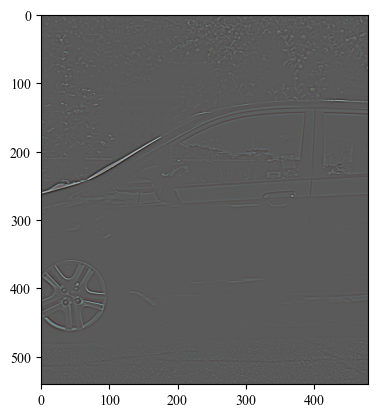

In [98]:
# load "C:\Users\dekav\VSC-Code\Visualization-Notebooks\Processed-Images\Processed_Images\Images\rgb\bild3-07-b.png"
#img = plt.imread("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_Images\\Images\\rgb\\bild3_d0_07-b.png")
img = plt.imread("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\sparsity07\\overlay_rgb\\overlay_rgb_original-RGB.png")
img_CO = plt.imread("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_Images\\Images\\rgb\\nef_rgb_blur_depth_5_sparsity_07-RGB.png")
#get rid of alpha channel if it exists
if img.shape[2] == 4:
    img = img[:, :, :3]
# save as integer values between 0 and 255
img = (img * 255).astype(np.uint8)

if img_CO.shape[2] == 4:
    img_CO = img_CO[:, :, :3]
# save as integer values between 0 and 255
img_CO = (img_CO * 255).astype(np.uint8)
plt.imshow(img_CO)

In [88]:
# print value that appears most often in the image
unique, counts = np.unique(img_CO, return_counts=True)
most_frequent_value = unique[np.argmax(counts)]
print(f"Most frequent value in the image: {most_frequent_value}")

Most frequent value in the image: 90


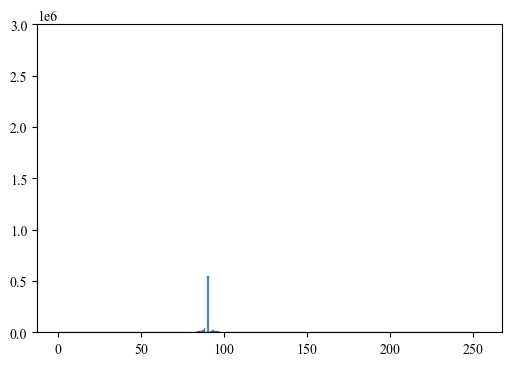

<Figure size 640x480 with 0 Axes>

In [83]:
# plot histogram of the image values
plot_value_distribution(torch.from_numpy(img_CO).float(), title="Value Distribution of Processed Image", save=True, bins=256, ylim=3000000)

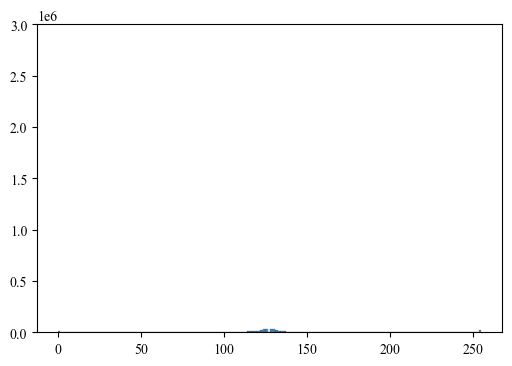

<Figure size 640x480 with 0 Axes>

In [ ]:
# load "C:\Users\dekav\VSC-Code\Visualization-Notebooks\Processed-Images\Processed_Images\Images\rgb\bild3-07-b.png"
#img = plt.imread("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_Images\\Images\\rgb\\bild3_d0_07-b.png")
img = plt.imread("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\sparsity07\\overlay_rgb\\overlay_rgb_sparse-RGB.png")
#get rid of alpha channel if it exists
if img.shape[2] == 4:
    img = img[:, :, :3]
# save as integer values between 0 and 255
img = (img * 255).astype(np.uint8)


plt.imshow(img)


In [ ]:
# get mask of img where pixels are equal to 255
mask = (img == [255, 255, 255]).all(axis=-1)
print("mask shape: ", mask.shape)
print("number of pixels equal to 255: ", mask.sum())

threshold_low = 89  # adjust if needed
threshold_high = 91

white_mask = (img_CO[:, :, 0] > threshold_low) & \
             (img_CO[:, :, 1] > threshold_low) & \
             (img_CO[:, :, 2] > threshold_low) & \
             (img_CO[:, :, 0] < threshold_high) & \
             (img_CO[:, :, 1] < threshold_high) & \
             (img_CO[:, :, 2] < threshold_high)
print("white mask shape: ", white_mask.shape)
print("number of pixels in white mask: ", white_mask.sum())
result = img

result[white_mask] = [255, 0, 255]

#save
plt.imsave("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_Images\\Images\\co\\nef_rgb_blur_depth_5_sparsity_07-Original-overlay.png", result)

# plot image

mask shape:  (541, 479)
number of pixels equal to 255:  0
white mask shape:  (541, 479)
number of pixels in white mask:  148110


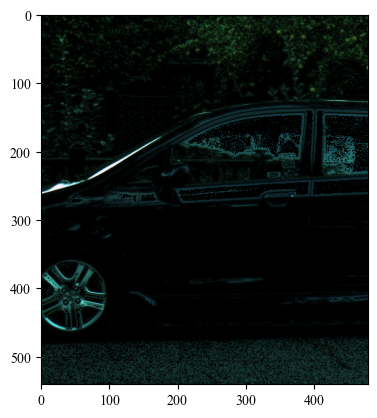

In [90]:
# get mask of img where pixels are equal to 255
mask = (img == [255, 255, 255]).all(axis=-1)
print("mask shape: ", mask.shape)
print("number of pixels equal to 255: ", mask.sum())

threshold_low = 89  # adjust if needed
threshold_high = 91

white_mask = (img_CO[:, :, 0] > threshold_low) & \
             (img_CO[:, :, 1] > threshold_low) & \
             (img_CO[:, :, 2] > threshold_low) & \
             (img_CO[:, :, 0] < threshold_high) & \
             (img_CO[:, :, 1] < threshold_high) & \
             (img_CO[:, :, 2] < threshold_high)
print("white mask shape: ", white_mask.shape)
print("number of pixels in white mask: ", white_mask.sum())
result = img

result[white_mask] = [0, 0, 0]

#save
#plt.imsave("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\Processed_Images\\Images\\co\\nef_rgb_blur_depth_5_sparsity_07-Original-overlay.png", result)

# plot image
plt.imshow(result)

In [44]:
# set white pixels to pink
img[mask] = [1.0, 0, 1.0]

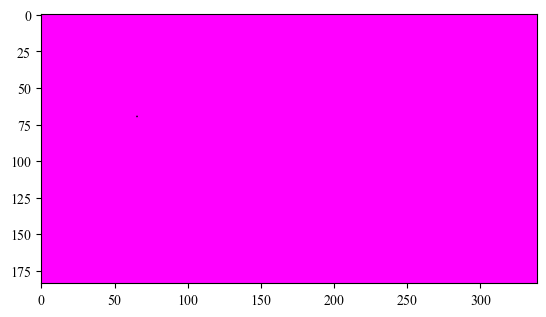

In [45]:
# plot image
plt.imshow(img)

In [23]:
#print img max
print("max value in img: ", img.max())

max value in img:  1.0


In [92]:
# print the value that appears most often in the image
from collections import Counter
counter = Counter(img.flatten())   
most_common_value, count = counter.most_common(1)[0]
print(f"The value that appears most often in the image is: {most_common_value} with a count of: {count}")

The value that appears most often in the image is: 128 with a count of: 74145


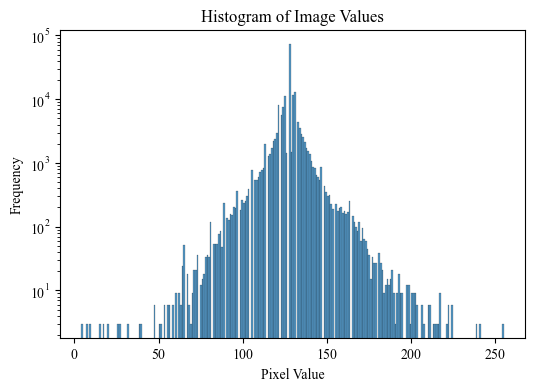

In [91]:
# plot histogram of img values
plt.figure(figsize=(6, 4))  
sns.histplot(img.flatten(), bins=256)#, kde=True)
plt.yscale('log')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Image Values')
plt.show()

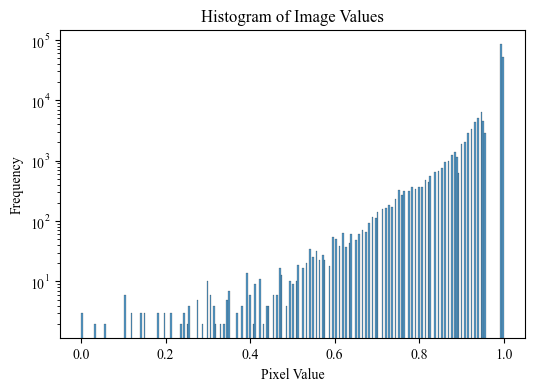

In [40]:
# plot histogram of img values
plt.figure(figsize=(6, 4))  
sns.histplot(img.flatten(), bins=256)#, kde=True)
plt.yscale('log')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Image Values')
plt.show()

#### Generation

##### Generate Images for Graphic with pink overlay for sparse areas

In [135]:
# Generate Images for Graphic with pink overlay for sparse areas
original_image_path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.nef"

original = load_raw_image_as_tensor(original_image_path)
x = torch.nn.functional.interpolate(original, scale_factor=0.5, mode='bilinear', align_corners=False, recompute_scale_factor=True)
processed = blur_module_rgb(x.to(blur_module_rgb.conv_blur.weight.device), "original_rgb")
sparse = sparse_module_07(processed)

x=crop_image(x[0]).cuda()
processed=crop_image(processed[0]).cuda()
sparse=crop_image(sparse[0]).cuda()

#save_image_with_overlay(x, processed, sparse, "overlay_rgb", "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\sparsity07\\overlay_rgb")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29113296..0.52152497].


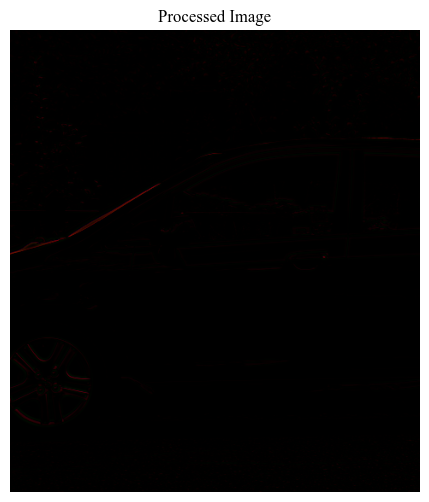

In [78]:
# plot processed image
plot_tensor_as_image(processed, title="Processed Image")

##### Distribution Plots

In [60]:
original_image_path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\cityscapes.png"
original = Image.open(original_image_path).convert('RGB')
original_tensor = transform(original).unsqueeze(0).to(blur_module_rgb.conv_blur.weight.device)
original_sparse = sparse_module_05(original_tensor)
processed = blur_module_rgb(original_tensor, "original_cityscapes")
sparse = sparse_module_07(processed)

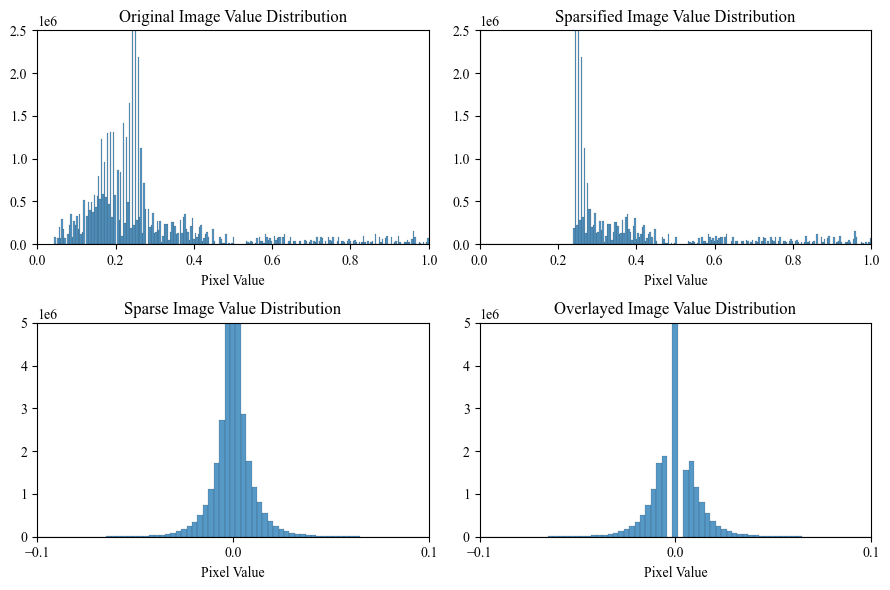

In [ ]:
bins = 256
# plot figure with 2x2 subplots: value distribution histrogramms from original image, processed image, sparse image and overlayed image
plt.figure(figsize=(9, 6))   
# set font to times new roman


plt.subplot(2, 2, 1)
sns.histplot(original_tensor[0].cpu().numpy().flatten(), bins=bins)
plt.title("Original Image Value Distribution")
plt.xlim(0, 1)
plt.ylim(0, 2500000)
plt.xlabel("Pixel Value")
plt.ylabel("") 
plt.subplot(2, 2, 2)
sns.histplot(original_sparse[0].cpu().numpy().flatten(), bins=bins)
plt.title("Sparsified Image Value Distribution")
plt.xlim(0, 1) 
plt.ylim(0, 2500000)
plt.xlabel("Pixel Value")
plt.ylabel("")
plt.subplot(2, 2, 3)
sns.histplot(processed[0].cpu().numpy().flatten(), bins=bins)
plt.title("Sparse Image Value Distribution")
plt.xlim(-0.1, 0.1)
plt.ylim(0, 5000000)
plt.xlabel("Pixel Value")
plt.ylabel("")
plt.subplot(2, 2, 4)
sns.histplot(sparse[0].cpu().numpy().flatten(), bins=bins)
plt.title("Sparsified Processed Image Value Distribution")
plt.xlim(-0.1, 0.1)
plt.ylim(0, 5000000)
plt.xlabel("Pixel Value")
plt.ylabel("")
# add spacing between rows so lower subplot titles have room
plt.subplots_adjust(hspace=0.3)
# Reduce x-axis tick label density only for the last two subplots (lower row)
axes = plt.gcf().get_axes()
# axes order is [ax1, ax2, ax3, ax4] for a 2x2 grid; keep every other tick for ax3 and ax4
for ax in axes[2:]:
    xt = ax.get_xticks()
    if len(xt) > 1:
        ax.set_xticks(xt[::2])
plt.tight_layout()
plt.show()

In [20]:
original_tensor = original
original_sparse = sparse_module_05(original_tensor)

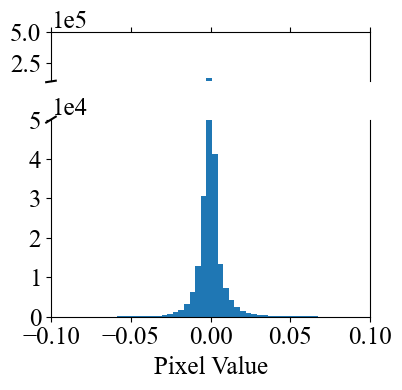

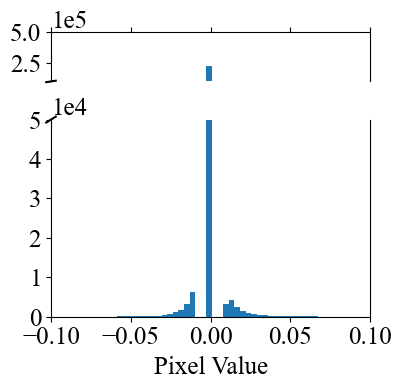

In [140]:
bins = 256
fontsize = 18

# --- Broken-axis example for the 'processed' histogram (pure Matplotlib) ---
data_proc = processed[0].cpu().numpy().flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
# lower (main) axis
ax_low.hist(data_proc, bins=bins, color='C0')
# upper axis to show tall bars
ax_high.hist(data_proc, bins=bins, color='C0')
ax_low.set_ylim(0, 50000)
ax_high.set_ylim(100000, 500000)
# hide spines between the two axes and add diagonal break markers
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.set_xlim(-0.1, 0.1)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015  # size of diagonal break mark in axes coordinates
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value", fontsize=fontsize)
#set font size
plt.setp(ax_low.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_low.yaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.yaxis.get_majorticklabels(), fontsize=fontsize)



# y axis in scientific notation
ax_low.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_high.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#enlarge fontsize
ax_low.yaxis.offsetText.set_fontsize(fontsize)
ax_high.yaxis.offsetText.set_fontsize(fontsize)
plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_processed.pdf", bbox_inches='tight')
plt.show()
# --- Broken-axis example for the 'sparse' histogram (pure Matplotlib) ---
data_sparse = sparse[0].cpu().numpy().flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
ax_low.hist(data_sparse, bins=bins, color='C0')
ax_low.set_ylim(0, 50000)
ax_high.hist(data_sparse, bins=bins, color='C0')
ax_high.set_ylim(100000, 500000)
ax_high.set_xlim(-0.1, 0.1)
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value", fontsize=fontsize)
#set font size
plt.setp(ax_low.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_low.yaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.yaxis.get_majorticklabels(), fontsize=fontsize)



# y axis in scientific notation
ax_low.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_high.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#enlarge fontsize
ax_low.yaxis.offsetText.set_fontsize(fontsize)
ax_high.yaxis.offsetText.set_fontsize(fontsize)
plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_processed_sparse.pdf", bbox_inches='tight')
plt.show()

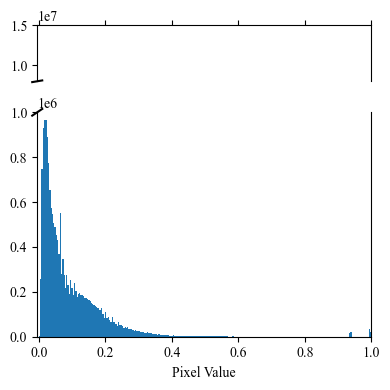

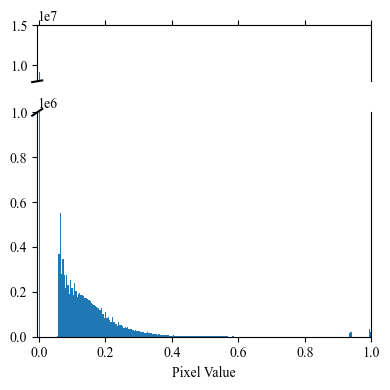

In [ ]:
bins = 256
# --- Broken-axis example for the 'processed' histogram (pure Matplotlib) ---
data_orig = original_tensor[0].cpu().numpy().flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
# lower (main) axis
ax_low.hist(data_orig, bins=bins, color='C0')
ax_low.set_ylim(0, 1000000)  # main y-range
# upper axis to show tall bars
ax_high.hist(data_orig, bins=bins, color='C0')
ax_high.set_ylim(8000000, 15000000)
# hide spines between the two axes and add diagonal break markers
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.set_xlim(-0.005, 1)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015  # size of diagonal break mark in axes coordinates
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value")
plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_original.pdf", bbox_inches='tight')
plt.show()
# --- Broken-axis example for the 'sparse' histogram (pure Matplotlib) ---
data_sparse = original_sparse[0].cpu().numpy().flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
ax_low.hist(data_sparse, bins=bins, color='C0')
ax_low.set_ylim(0, 1000000)  # main y-range
ax_high.hist(data_sparse, bins=bins, color='C0')
ax_high.set_ylim(8000000, 15000000)
ax_high.set_xlim(-0.005, 1)
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value")
plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_original_sparse.pdf", bbox_inches='tight')
plt.show()

In [ ]:
print(original_sparse[0].cpu().numpy().flatten().shape)
print(data_sparse.shape)

(18294720,)
(777417,)


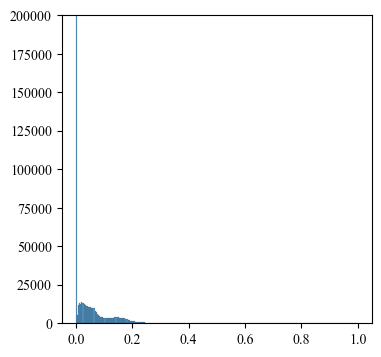

In [110]:

#histogram of original image values without broken axis
plot_value_distribution(torch.from_numpy(result/255.0).float(), title="Value Distribution of Original Image with sparse mask of processed image", save=True, bins=256, ylim=200000)

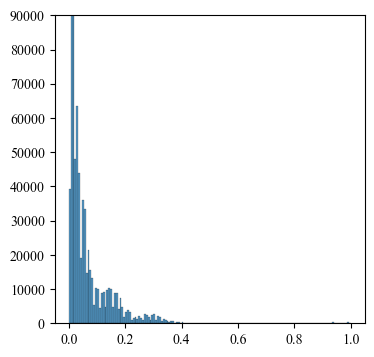

In [116]:

#histogram of original image values without broken axis
plot_value_distribution(torch.from_numpy(img/255.0).float(), title="Value Distribution of Original Image", save=True, bins=150, ylim=90000)


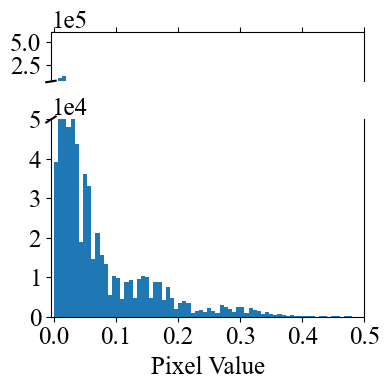

In [133]:
bins = 150
fontsize = 18
data_sparse = (img/255.0).flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
ax_low.hist(data_sparse, bins=bins, color='C0')
ax_low.set_ylim(0, 50000)  # main y-range
ax_high.hist(data_sparse, bins=bins, color='C0')
ax_high.set_ylim(80000, 600000)
ax_high.set_xlim(-0.005, 0.5)
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value", fontsize=fontsize)

#set font size
plt.setp(ax_low.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_low.yaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.yaxis.get_majorticklabels(), fontsize=fontsize)



# y axis in scientific notation
ax_low.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_high.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#enlarge fontsize
ax_low.yaxis.offsetText.set_fontsize(fontsize)
ax_high.yaxis.offsetText.set_fontsize(fontsize)
plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_original_-processed_orig.pdf", bbox_inches='tight')
plt.show()

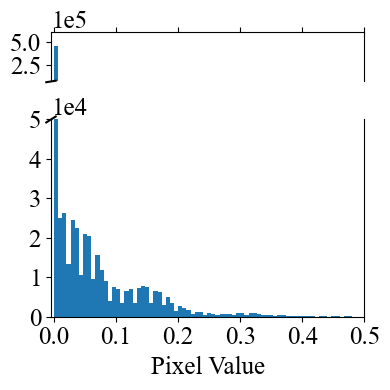

In [132]:

fontsize = 18
data_sparse = (result/255.0).flatten()
fig, (ax_high, ax_low) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1,4]}, figsize=(4, 4))
ax_low.hist(data_sparse, bins=bins, color='C0')
ax_low.set_ylim(0, 50000)  # main y-range
ax_high.hist(data_sparse, bins=bins, color='C0')
ax_high.set_ylim(80000, 600000)
ax_high.set_xlim(-0.005, 0.5)
ax_high.spines['bottom'].set_visible(False)
ax_low.spines['top'].set_visible(False)
ax_high.xaxis.tick_top()
ax_high.tick_params(labeltop=False)
d = .015
kwargs = dict(transform=ax_low.transAxes, color='k', clip_on=False)
ax_low.plot((-d, +d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax_high.transAxes)
ax_high.plot((-d, +d), (-d, +d), **kwargs)
ax_low.set_xlabel("Pixel Value", fontsize=fontsize)
#set font size
plt.setp(ax_low.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.xaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_low.yaxis.get_majorticklabels(), fontsize=fontsize)
plt.setp(ax_high.yaxis.get_majorticklabels(), fontsize=fontsize)



# y axis in scientific notation
ax_low.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax_high.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#enlarge fontsize
ax_low.yaxis.offsetText.set_fontsize(fontsize)
ax_high.yaxis.offsetText.set_fontsize(fontsize)

plt.tight_layout()
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions\\nef_distribution_original_-processed_sparse.pdf", bbox_inches='tight')
plt.show()

# REST

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4581258..0.6251676].


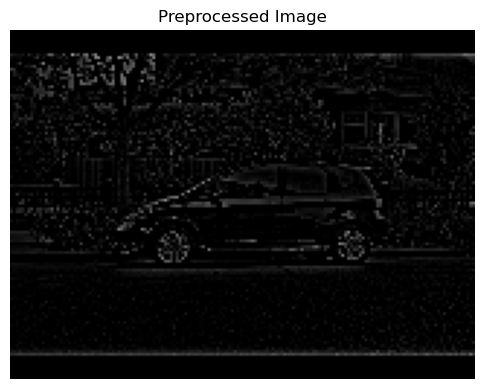

In [9]:
result = visualize_preprocessing("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.nef", blur_module_bw, sparse_module_00)

# plot result
plot_tensor_as_image(result[0], title="Preprocessed Image")

In [51]:
path = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\cityscapes.png"
#path =  "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Processed-Images\\images\\2014_000982.nef"

original_image = Image.open(path).convert('RGB')
#original_tensor = load_raw_image_as_tensor(path)

original_tensor = transform(original_image).unsqueeze(0)

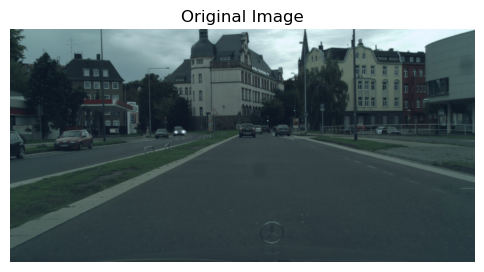

In [52]:


# cut the original tensor top and bottom for 20% each to focus on the center part of the image
#height = original_tensor.shape[2]
#cut_top = int(height * 0.2)
#cut_bottom = int(height * 0.8)
#original_tensor = original_tensor[:, :, cut_top:cut_bottom, :]

#original_tensor = crop_image_helper(original_tensor[0]).unsqueeze(0)

# plot original tensor
plot_tensor_as_image(original_tensor[0], title="Original Image")

# blur image with torch gaussian blur for better visualization of sparsity
#gaussian_blur = T.GaussianBlur(kernel_size=11, sigma=2.0)
#blurred_tensor = gaussian_blur(original_tensor)

# save blurred image
#save_image_rgb(blurred_tensor[0], "result", "original_blurred", 3, "images/cityscapes_blur", True)


In [53]:

original_sparse = sparse_module_07(original_tensor)
result = visualize_preprocessing(path, blur_module_bw, sparse_module_00)
result_sparse_07 = visualize_preprocessing(path, blur_module_bw, sparse_module_07)

In [34]:
# save the original image, the preprocessed image and the sparse image with sparsity 0.7 as pdfs rgb
save_image_rgb(original_tensor[0], "result", "original_image", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(result[0].abs(), "result", "preprocessed_image", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(result_sparse_07[0].abs(), "result", "sparse_image_07", 3, "Processed_Images/Images/sparse-figure", False)
save_image_rgb(original_sparse[0], "result", "original_sparse_image_07", 3, "Processed_Images/Images/sparse-figure", False)

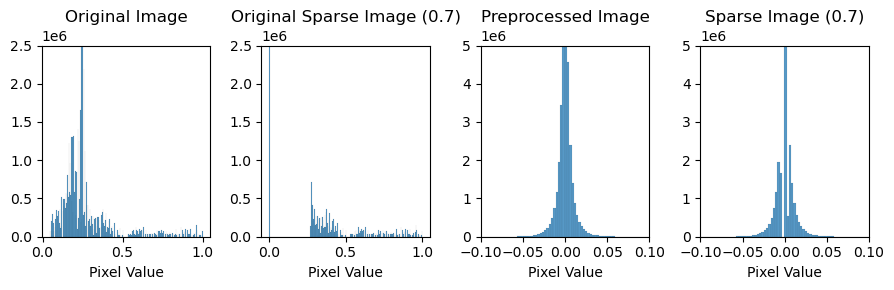

In [ ]:
# plot distributions of original image, original sparse, preprocessed image and sparse image with sparsity 0.7 in one row with shared y-axis
plt.figure(figsize=(9, 3))
plt.subplot(1, 4, 1)    
sns.histplot(original_tensor.cpu().numpy().flatten(), bins=256)
plt.title("Original Image")
plt.xlabel("Pixel Value")
plt.ylim(0, 2500000)
plt.ylabel("")
plt.subplot(1, 4, 2)
sns.histplot(original_sparse.cpu().numpy().flatten(), bins=256)
plt.title("Original Sparse Image (0.7)")
plt.xlabel("Pixel Value")
plt.ylim(0, 2500000)
plt.ylabel("")
plt.subplot(1, 4, 3)
sns.histplot(result.cpu().numpy().flatten(), bins=256)
plt.title("Preprocessed Image")
plt.xlabel("Pixel Value")
plt.ylim(0, 5000000)
plt.xlim(-0.1,0.1)
plt.ylabel("")
plt.subplot(1, 4, 4)
sns.histplot(result_sparse_07.cpu().numpy().flatten(), bins=256)
plt.title("Sparse Image (0.7)")
plt.xlabel("Pixel Value")
plt.ylim(0, 5000000)
plt.xlim(-0.1,0.1)
plt.ylabel("")
# Reduce x-axis tick label density by keeping every other tick for all subplots
for ax in plt.gcf().get_axes():
    xt = ax.get_xticks()
    if len(xt) > 1:
        ax.set_xticks(xt[::2])
plt.tight_layout()

plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distribution_comparison.pdf", bbox_inches='tight')
plt.show()

In [96]:
# save plot as pdf
plt.savefig("C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Figure-PDFs\\value_distributions.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

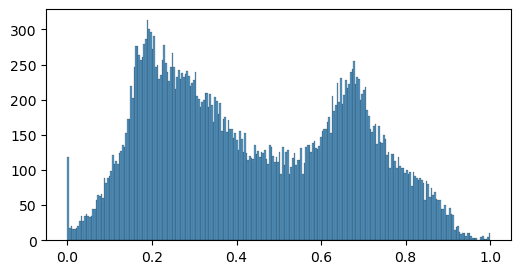

<Figure size 640x480 with 0 Axes>

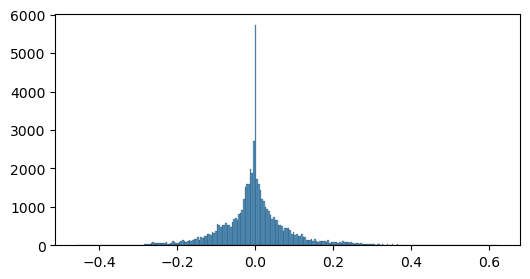

<Figure size 640x480 with 0 Axes>

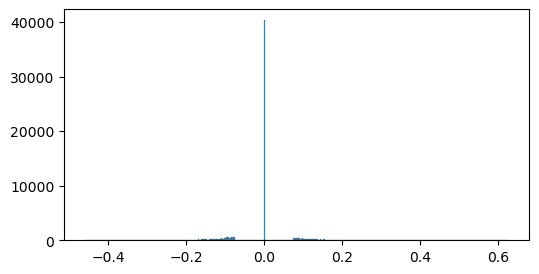

<Figure size 640x480 with 0 Axes>

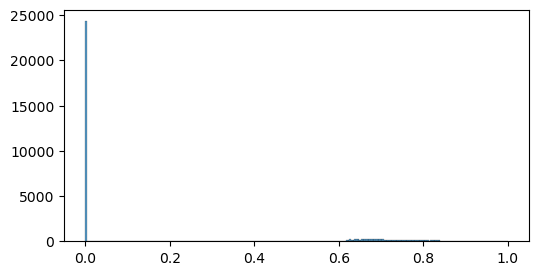

<Figure size 640x480 with 0 Axes>

In [91]:
save = True

plot_value_distribution(original_tensor, title="distribution_original", bins=256, save=save)
plot_value_distribution(result, title="distribution_preprocessed", bins=256, save=save)
plot_value_distribution(result_sparse_07, title="distribution_preprocessed_07", bins=256, save=save)
plot_value_distribution(original_sparse, title="distribution_original_07", bins=256, save=save)

##### Plotting the Distributions

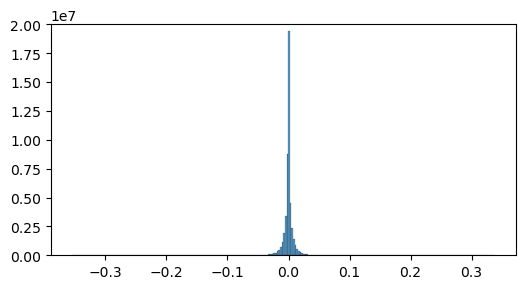

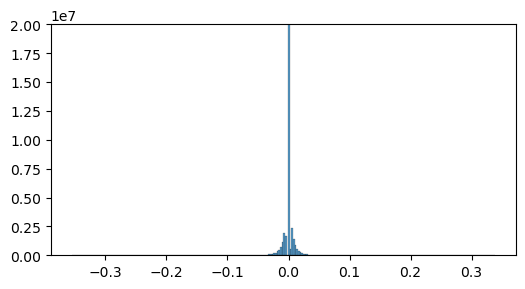

In [ ]:
plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_07, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)

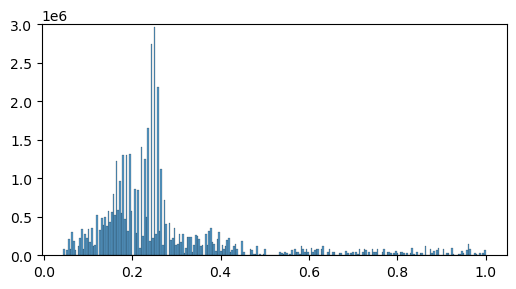

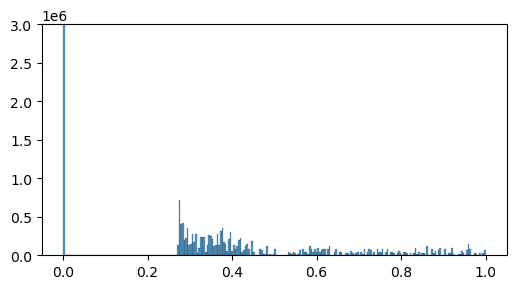

In [60]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

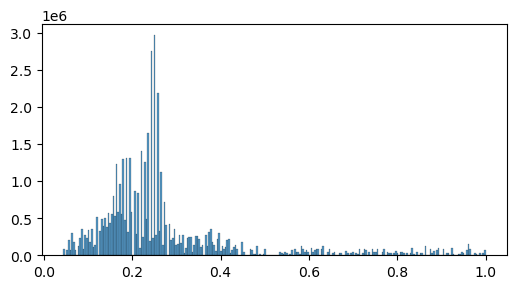

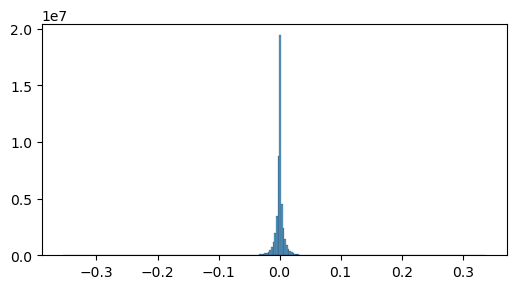

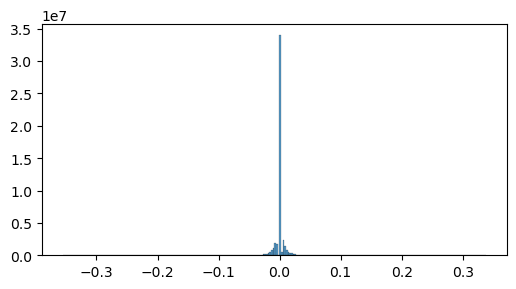

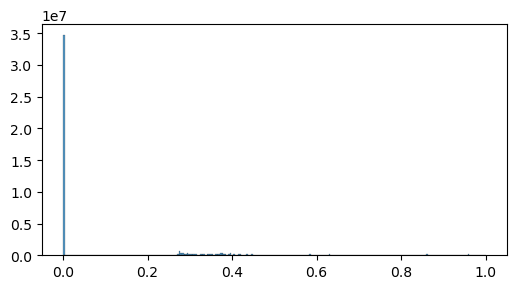

In [ ]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_07, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

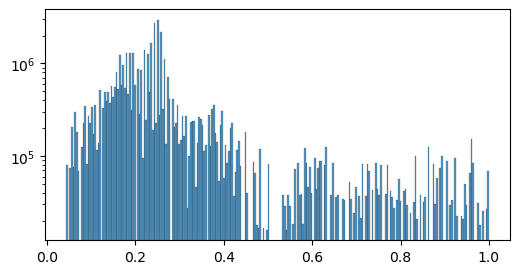

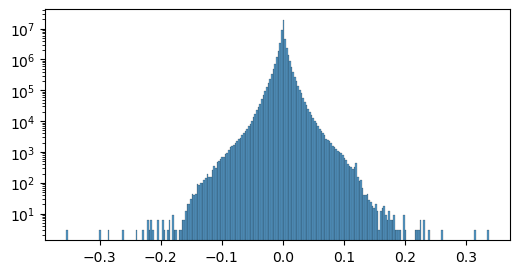

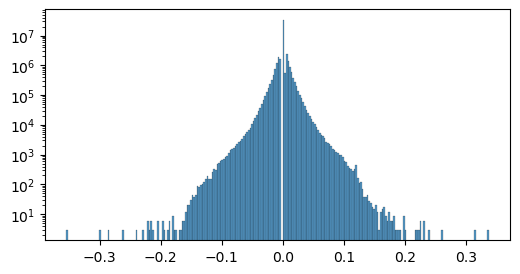

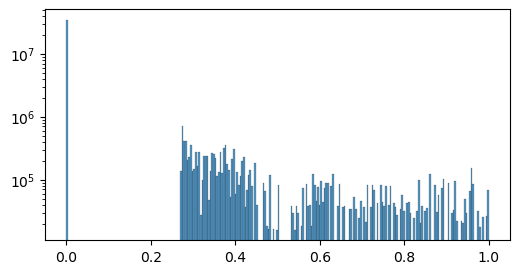

In [ ]:
plot_value_distribution(original_tensor, title="Original Image Value Distribution", bins=256)
plot_value_distribution(result, title="Preprocessed Image Value Distribution", bins=256)
plot_value_distribution(result_sparse_07, title="Preprocessed Image with 70% Sparsity Value Distribution", bins=256)
plot_value_distribution(original_sparse, title="Original Image with 70% Sparsity Value Distribution", bins=256)

##### Something else